=== LOGISTIC REGRESSION RESULTS ===
Accuracy : 92.50%
Precision: 1.0000
Recall   : 0.8696
F1 Score : 0.9302

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       1.00      0.87      0.93        23

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.94      0.93      0.93        40


[SUCCESS] Saved visualization plot as 'logistic_regression_results.png'


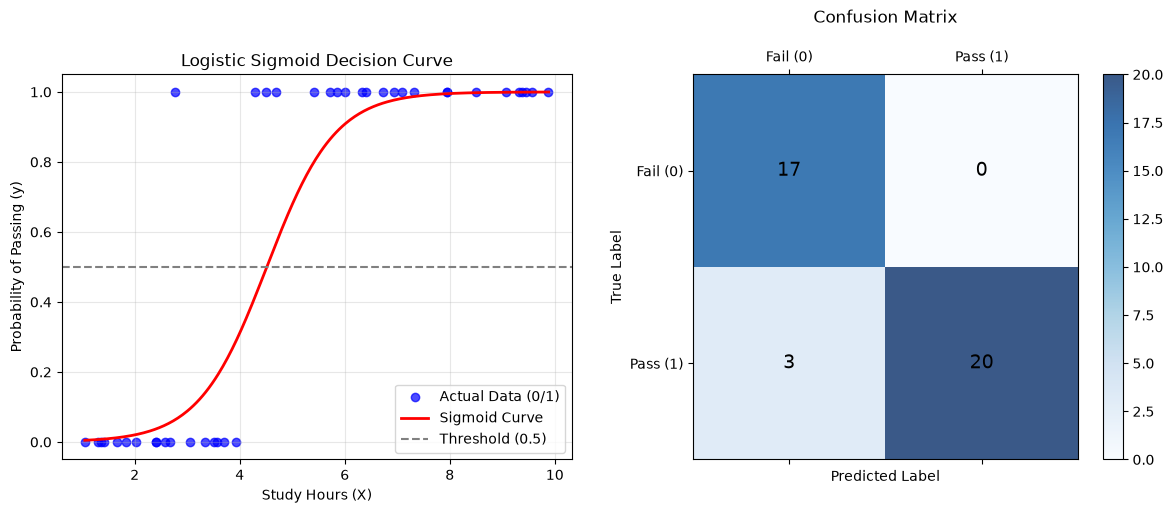

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
#geneeate raw data
np.random.seed(42)
# Feature: Study hours (1 to 10 hours)
X = np.random.uniform(1, 10, (200, 1))
# Generate target: 0 (Fail) or 1 (Pass) using sigmoid probability
linear_combination = -4 + 0.9 * X.ravel() + np.random.normal(0, 0.5, 200)
probabilities = 1 / (1 + np.exp(-linear_combination))
y = (probabilities > 0.5).astype(int)
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#train logistic model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
# Make Predictions
y_pred = log_model.predict(X_test_scaled)
#print evaluation metrics
print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
#generate plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# --- Plot 1: Sigmoid Decision Boundary ---
axes[0].scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Data (0/1)')
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_range_prob = log_model.predict_proba(scaler.transform(X_range))[:, 1]
axes[0].plot(X_range, y_range_prob, color='red', linewidth=2, label='Sigmoid Curve')
axes[0].axhline(0.5, color='gray', linestyle='--', label='Threshold (0.5)')
axes[0].set_title('Logistic Sigmoid Decision Curve')
axes[0].set_xlabel('Study Hours (X)')
axes[0].set_ylabel('Probability of Passing (y)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
cax = axes[1].matshow(cm, cmap='Blues', alpha=0.8)
fig.colorbar(cax, ax=axes[1])

axes[1].set_title('Confusion Matrix', pad=20)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Fail (0)', 'Pass (1)'])
axes[1].set_yticklabels(['Fail (0)', 'Pass (1)'])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, color='black')

plt.tight_layout()

# Save image file to current directory
plt.savefig('logistic_regression_results.png', dpi=300)
print("\n[SUCCESS] Saved visualization plot as 'logistic_regression_results.png'")

# Display plot window
plt.show()

In [6]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data.copy()
y = boston.target.copy()

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

data = pd.concat([X, y.rename("PRICE")], axis=1)
data.dropna(inplace=True)

X = data.drop("PRICE", axis=1)
y = data["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

best_model = results_df.iloc[0]

print("\nBest Model")
print("Model :", best_model["Model"])
print("MAE   :", round(best_model["MAE"], 3))
print("RMSE  :", round(best_model["RMSE"], 3))
print("R2    :", round(best_model["R2 Score"], 3))

                      Model       MAE      RMSE  R2 Score
2             Random Forest  2.036735  2.807172  0.892543
1             Decision Tree  2.724510  4.220852  0.757062
0         Linear Regression  3.189092  4.928602  0.668759
3  Support Vector Regressor  2.731716  5.066413  0.649977

Best Model
Model : Random Forest
MAE   : 2.037
RMSE  : 2.807
R2    : 0.893
